# Определение возрастной категории пользователей

Автор: Кезлинг Владислав

Дата: 20.04.2026

--------------------

**Цель:** 
- Разработать модель многоклассовой классификации для определения возрастной категории пользователей.

**Задачи:**
- Провести исследовательский анализ данных.
- Предобработать данные.
- Обучить базовую модель.
- Провести создание и отбор признаков.
- Подобрать гиперпараметры.

**Критерии успешности:**
- Значение F1-score должно быть не ниже 0.75.
- Сохранение обученной модели и пайплайна предобработки для дальнейшего внедрения.

--------------------

## Подготовка среды и библиотек

### Подготовка библиотек 

In [1]:
# ---------------------------------------------------------
# установка необходимых библиотек (флаг, чтобы не показывались логи)
!pip install pandas "numpy<2" scipy numba joblib matplotlib seaborn -q 
!pip install --upgrade scikit-learn -q
# ---------------------------------------------------------

# ---------------------------------------------------------
# проверка версий для requirements.txt
!pip freeze > requirements.txt
# ---------------------------------------------------------

# ---------------------------------------------------------
# импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import seaborn as sns
import joblib
import os

# skleaern
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.feature_selection import VarianceThreshold, RFE, mutual_info_classif, SelectKBest
# ---------------------------------------------------------

import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# настройка отображения графиков
plt.style.use('ggplot')  
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# настройка отображения датафреймов
pd.set_option('display.max_columns', 50)     
pd.set_option('display.max_rows', 100)      
pd.set_option('display.precision', 3)        
pd.set_option('display.float_format', '{:.3f}'.format)
# ---------------------------------------------------------

# ---------------------------------------------------------
# вывод, чтобы удостоверится, что процесс выполнен
print('Выполнено')
# ---------------------------------------------------------

Выполнено


### Фиксация Random_State

In [2]:
# фиксация
RANDOM_STATE = 42

### Загрузка данных

In [3]:
# Список датасетов
datasets = {
    'df_users': 'datasets/ds_s13_users.csv',
    'df_visits': 'datasets/ds_s13_visits.csv',
    'df_activity': 'datasets/ads_activity.csv',
    'df_depth': 'datasets/surf_depth.csv',
    'df_device': 'datasets/primary_device.csv',
    'df_usage': 'datasets/cloud_usage.csv'
}

# Словарь для сохранения (цикл для загрузки и вывода информации о датасете)
data = {}

for name, path in datasets.items():
    print('-' * 50)
    print(f"Загрузка: {name}")
    
    df = pd.read_csv(path)
    
    print("Размер:", df.shape)
    print("Столбцы:", df.columns.tolist())
    
    data[name] = df

# Сохраняем в отдельные переменные для удобства
df_users = data['df_users']
df_visits = data['df_visits']
df_activity = data['df_activity']
df_depth = data['df_depth']
df_device = data['df_device']
df_usage = data['df_usage']

print('-' * 50)
print("\nДатасеты загружены")

--------------------------------------------------
Загрузка: df_users
Размер: (5913, 2)
Столбцы: ['user_id', 'age_category']
--------------------------------------------------
Загрузка: df_visits
Размер: (1065745, 5)
Столбцы: ['date', 'daytime', 'session_id', 'user_id', 'website_category']
--------------------------------------------------
Загрузка: df_activity
Размер: (5826, 2)
Столбцы: ['user_id', 'ads_activity']
--------------------------------------------------
Загрузка: df_depth
Размер: (5715, 2)
Столбцы: ['user_id', 'surf_depth']
--------------------------------------------------
Загрузка: df_device
Размер: (5669, 2)
Столбцы: ['user_id', 'primary_device']
--------------------------------------------------
Загрузка: df_usage
Размер: (5680, 2)
Столбцы: ['user_id', 'cloud_usage']
--------------------------------------------------

Датасеты загружены


### Вывод по пункту

- Импортированны необходимые библиотеки, зафиксирована константа для воспроизводимости результатов.
- Загружены дадасеты и выведена их основная информация.

----------
## Исследовательский анализ данных

**План:**
- Проверить все датасеты на наличие: пропусков, дубликатов, аномалий.
- Проверить распределение значений в целевом признаке
- Составить план предобработки

--------
### Проверка "основного" датасета  

Данный датасет, можно назвать "основным", так как в нём расположена целевая переменная "age_category". 

In [4]:
# df_users
# ------------------------------------------------------
#размер до пропусков
print("Размер датасета:", df_users.shape)

# ищем пропуски
print('\nПропусков:')
print(df_users.isnull().sum())

# проверка на дубликаты
print('\nДубликатов:',df_users.duplicated().sum())

# уникальные значения 
print('\nЗначения'),
print(df_users['age_category'].unique())

print('\nКол-во значений')
print(df_users.nunique())

print('\nОбщая информация:')
df_users.info()

# описание данных
print('\nОписание данных')
df_users.describe().round(2)

Размер датасета: (5913, 2)

Пропусков:
user_id         0
age_category    0
dtype: int64

Дубликатов: 87

Значения
[4 2 0 1 3]

Кол-во значений
user_id         5826
age_category       5
dtype: int64

Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5913 non-null   object
 1   age_category  5913 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 92.5+ KB

Описание данных


,age_category
count,5913.000
mean,2.440
std,1.380
min,0.000
25%,2.000
50%,3.000
75%,4.000
max,4.000


Количество:
age_category
4    1794
2    1467
3    1269
0     863
1     520
Name: count, dtype: int64

Процентное соотношение:
age_category
4   30.340
2   24.810
3   21.461
0   14.595
1    8.794
Name: proportion, dtype: float64 %


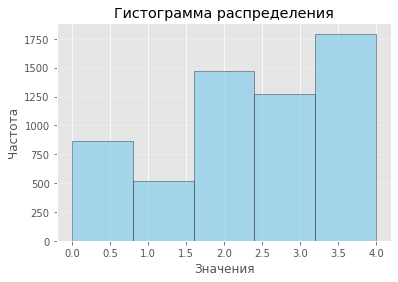

In [5]:
# Смотрим распределение целевой переменной
# -------------------------------------------------------
counts = df_users['age_category'].value_counts()
percent = df_users['age_category'].value_counts(normalize=True) * 100

print("Количество:")
print(counts)

print("\nПроцентное соотношение:")
print(percent,'%')
# -------------------------------------------------------

# Визуализируем
# -------------------------------------------------------
# гистограмма распределения 
plt.hist(df_users['age_category'].values, bins=5, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Гистограмма распределения')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.show()
# -------------------------------------------------------

**Промежуточный вывод:**
- Был проверен датасет df_users.
- Пропусков не обнаружено.
- Полных дубликатов 87, и так как их мало (+-1,5%), их можно удалить.
- В целевой переменной надлюдается дизбаланс классов. Меньше всего значений в 1 категории - (от 18 до 25 лет)

--------
### Проверка датасета: df_activity

In [6]:
# df_activity
# ------------------------------------------------------
#размер до пропусков
print("Размер датасета:", df_activity.shape)

# ищем пропуски
print('\nПропусков:'),
print(df_activity.isnull().sum())

# проверка на дубликаты
print('\nДубликатов:',df_activity.duplicated().sum())

# уникальные значения 
print('\nЗначения'),
print(df_activity['ads_activity'].unique())

print('\nКол-во значений')
print(df_activity.nunique())


print('\nОбщая информация:')
df_activity.info()

# описание данных
print('\nОписание данных')
df_activity.describe().round(2)

Размер датасета: (5826, 2)

Пропусков:
user_id         0
ads_activity    0
dtype: int64

Дубликатов: 233

Значения
['очень часто' 'редко' 'очень редко' 'умеренно' 'часто']

Кол-во значений
user_id         5593
ads_activity       5
dtype: int64

Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5826 non-null   object
 1   ads_activity  5826 non-null   object
dtypes: object(2)
memory usage: 91.2+ KB

Описание данных


,user_id,ads_activity
count,5826,5826
unique,5593,5
top,168a-d84a1e43b19b278f770a-63214e42,умеренно
freq,2,1897


Количество:
ads_activity
умеренно       1897
редко          1698
часто          1112
очень редко     881
очень часто     238
Name: count, dtype: int64

Процентное соотношение:
ads_activity
умеренно      32.561
редко         29.145
часто         19.087
очень редко   15.122
очень часто    4.085
Name: proportion, dtype: float64 %


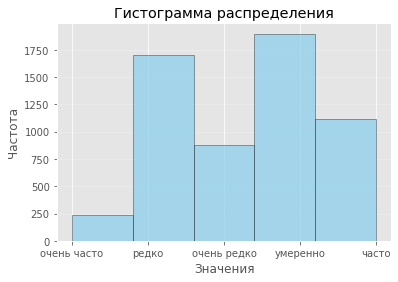

In [7]:
# Смотрим распределение 
# -------------------------------------------------------
counts = df_activity['ads_activity'].value_counts()
percent = df_activity['ads_activity'].value_counts(normalize=True) * 100

print("Количество:")
print(counts)

print("\nПроцентное соотношение:")
print(percent,'%')
# -------------------------------------------------------

# Визуализируем
# -------------------------------------------------------
# гистограмма распределения 
plt.hist(df_activity['ads_activity'].values, bins=5, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Гистограмма распределения')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.show()
# -------------------------------------------------------

**Промежуточный вывод:**
- Был проверен датасет df_activity.
- Пропусков не обнаружено.
- Полных дубликатов 233, чтобы оставить только уникальных пользователей, дубликаты нужно удалить.
- В категориальном признаке "ads_activity" самое частое значение - "умеренно", а "очень часто" самое редкое.

###  Проверка датасета: df_depth

In [8]:
# df_depth
# ------------------------------------------------------
#размер до пропусков
print("Размер датасета:", df_depth.shape)

# ищем пропуски
print('\nПропусков:'),
print(df_depth.isnull().sum())

# проверка на дубликаты
print('\nДубликатов:',df_depth.duplicated().sum())

# уникальные значения 
print('\nЗначения'),
print(df_depth['surf_depth'].unique())

print('\nКол-во значений')
print(df_depth.nunique())


print('\nОбщая информация:')
df_depth.info()

# описание данных
print('\nОписание данных')
df_depth.describe().round(2)

Размер датасета: (5715, 2)

Пропусков:
user_id       0
surf_depth    0
dtype: int64

Дубликатов: 0

Значения
['поверхностно' 'глубоко' 'средне']

Кол-во значений
user_id       5715
surf_depth       3
dtype: int64

Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     5715 non-null   object
 1   surf_depth  5715 non-null   object
dtypes: object(2)
memory usage: 89.4+ KB

Описание данных


,user_id,surf_depth
count,5715,5715
unique,5715,3
top,f238-0c4c1e787cce311541b7-736925a0,средне
freq,1,2435


Количество:
surf_depth
средне          2435
поверхностно    2424
глубоко          856
Name: count, dtype: int64

Процентное соотношение:
surf_depth
средне         42.607
поверхностно   42.415
глубоко        14.978
Name: proportion, dtype: float64 %


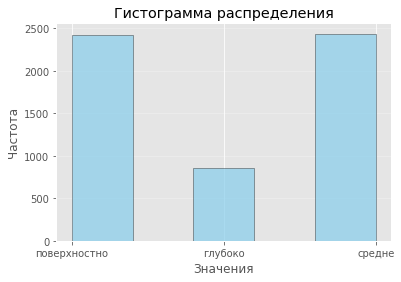

In [9]:
# Смотрим распределение 
# -------------------------------------------------------
counts = df_depth['surf_depth'].value_counts()
percent = df_depth['surf_depth'].value_counts(normalize=True) * 100

print("Количество:")
print(counts)

print("\nПроцентное соотношение:")
print(percent,'%')
# -------------------------------------------------------

# Визуализируем
# -------------------------------------------------------
# гистограмма распределения 
plt.hist(df_depth['surf_depth'].values, bins=5, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Гистограмма распределения')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.show()
# -------------------------------------------------------

**Промежуточный вывод:**
- Был проверен датасет df_depth.
- Пропусков не обнаружено.
- Дубликатов не обнаружено.
- В категориальном признаке "surf_depth", значения "поверхностно" и "средне" распределены одинаково (42%), а "глубоко" самое редкое.

###  Проверка датасета: df_device

In [10]:
# df_device
# ------------------------------------------------------
#размер до пропусков
print("Размер датасета:", df_device.shape)

# ищем пропуски
print('\nПропусков:'),
print(df_device.isnull().sum())

# проверка на дубликаты
print('\nДубликатов:',df_device.duplicated().sum())

# уникальные значения 
print('\nЗначения'),
print(df_device['primary_device'].unique())

print('\nКол-во значений')
print(df_device.nunique())


print('\nОбщая информация:')
df_device.info()

# описание данных
print('\nОписание данных')
df_device.describe().round(2)

Размер датасета: (5669, 2)

Пропусков:
user_id           0
primary_device    0
dtype: int64

Дубликатов: 0

Значения
['смартфон' 'ПК' 'ноутбук' 'планшет']

Кол-во значений
user_id           5669
primary_device       4
dtype: int64

Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         5669 non-null   object
 1   primary_device  5669 non-null   object
dtypes: object(2)
memory usage: 88.7+ KB

Описание данных


,user_id,primary_device
count,5669,5669
unique,5669,4
top,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
freq,1,3083


Количество:
primary_device
смартфон    3083
ПК          1275
ноутбук      923
планшет      388
Name: count, dtype: int64

Процентное соотношение:
primary_device
смартфон   54.383
ПК         22.491
ноутбук    16.282
планшет     6.844
Name: proportion, dtype: float64 %


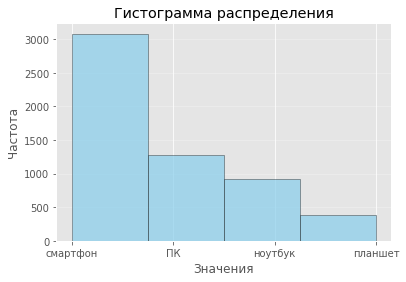

In [11]:
# Смотрим распределение 
# -------------------------------------------------------
counts = df_device['primary_device'].value_counts()
percent = df_device['primary_device'].value_counts(normalize=True) * 100

print("Количество:")
print(counts)

print("\nПроцентное соотношение:")
print(percent,'%')
# -------------------------------------------------------

# Визуализируем
# -------------------------------------------------------
# гистограмма распределения 
plt.hist(df_device['primary_device'].values, bins=4, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Гистограмма распределения')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.show()
# -------------------------------------------------------

**Промежуточный вывод:**
- Был проверен датасет df_device.
- Пропусков не обнаружено.
- Дубликатов не обнаружено.
- В категориальном признаке "primary_device", значения расположены "обратной лесенкой" от (большего) "смартфон" к (меньшему) "планшет".

### Проверка датасета: df_usage

In [12]:
# df_usage
# ------------------------------------------------------
#размер до пропусков
print("Размер датасета:", df_usage.shape)

# ищем пропуски
print('\nПропусков:'),
print(df_usage.isnull().sum())

# проверка на дубликаты
print('\nДубликатов:',df_usage.duplicated().sum())

# уникальные значения 
print('\nЗначения'),
print(df_usage['cloud_usage'].unique())

print('\nКол-во значений')
print(df_usage.nunique())


print('\nОбщая информация:')
df_usage.info()

# описание данных
print('\nОписание данных')
df_usage.describe().round(2)

Размер датасета: (5680, 2)

Пропусков:
user_id        0
cloud_usage    0
dtype: int64

Дубликатов: 0

Значения
[False  True]

Кол-во значений
user_id        5680
cloud_usage       2
dtype: int64

Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      5680 non-null   object
 1   cloud_usage  5680 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 50.0+ KB

Описание данных


,user_id,cloud_usage
count,5680,5680
unique,5680,2
top,a1e4-91c8a52eb855595e653f-298ce305,True
freq,1,2951


Количество:
cloud_usage
True     2951
False    2729
Name: count, dtype: int64

Процентное соотношение:
cloud_usage
True    51.954
False   48.046
Name: proportion, dtype: float64 %


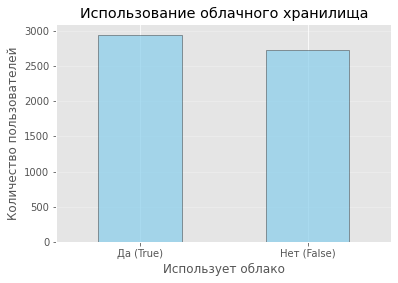

In [13]:
# Смотрим распределение 
# -------------------------------------------------------
counts = df_usage['cloud_usage'].value_counts()
percent = df_usage['cloud_usage'].value_counts(normalize=True) * 100

print("Количество:")
print(counts)

print("\nПроцентное соотношение:")
print(percent,'%')
# -------------------------------------------------------

# Визуализируем
# -------------------------------------------------------
# гистограмма распределения 
df_usage['cloud_usage'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Использование облачного хранилища')
plt.xlabel('Использует облако')
plt.ylabel('Количество пользователей')
plt.xticks([0, 1], ['Да (True)', 'Нет (False)'], rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()
# -------------------------------------------------------

**Промежуточный вывод:**
- Был проверен датасет df_usage.
- Пропусков не обнаружено.
- Дубликатов не обнаружено.
- В бинарном признаке "cloud_usage", значения расположены примерно одинаково True(Да) - 51%, False(Нет) - 48%.

### Проверка датасета: df_visits

In [14]:
# df_visits
# ------------------------------------------------------
#размер до пропусков
print("Размер датасета:", df_visits.shape)

# ищем пропуски
print('\nПропусков:'),
print(df_visits.isnull().sum())

# проверка на дубликаты
print('\nДубликатов:',df_visits.duplicated().sum())

# уникальные значения 
print('\nЗначения daytime'),
print(df_visits['daytime'].unique())
# ---------------------------
# уникальные значения 
print('\nЗначения website_category'),
print(df_visits['website_category'].unique())

print('\nКол-во значений')
print(df_visits.nunique())


print('\nОбщая информация:')
df_visits.info()

# описание данных
print('\nОписание данных')
df_visits.describe().round(2)

Размер датасета: (1065745, 5)

Пропусков:
date                0
daytime             0
session_id          0
user_id             0
website_category    0
dtype: int64

Дубликатов: 15750

Значения daytime
['вечер' 'день' 'ночь' 'утро']

Значения website_category
['Category 17' 'Category 19' 'Category 18' 'Category 20' 'Category 05'
 'Category 12' 'Category 03' 'Category 15' 'Category 10' 'Category 06'
 'Category 04' 'Category 09' 'Category 01' 'Category 11' 'Category 07'
 'Category 14' 'Category 08' 'Category 13' 'Category 02' 'Category 16']

Кол-во значений
date                     14
daytime                   4
session_id          1049995
user_id                5826
website_category         20
dtype: int64

Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   date              1065745 non-null  object
 1   dayti

,date,daytime,session_id,user_id,website_category
count,1065745,1065745,1065745,1065745,1065745
unique,14,4,1049995,5826,20
top,2025-11-13,день,d428ace6-8e86-4127-b653-c8ae3c1d0443,5ff2-0a5aa967e353041283b9-ff7929cc,Category 03
freq,76599,389052,2,853,70260


Количество:
daytime
день     389052
вечер    382098
утро     211500
ночь      83095
Name: count, dtype: int64

Процентное соотношение:
daytime
день    36.505
вечер   35.853
утро    19.845
ночь     7.797
Name: proportion, dtype: float64 %


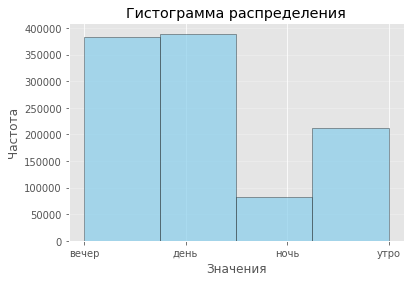

In [15]:
# Смотрим распределение daytime
# -------------------------------------------------------
counts = df_visits['daytime'].value_counts()
percent = df_visits['daytime'].value_counts(normalize=True) * 100

print("Количество:")
print(counts)

print("\nПроцентное соотношение:")
print(percent,'%')
# -------------------------------------------------------

# Визуализируем
# -------------------------------------------------------
# гистограмма распределения 
plt.hist(df_visits['daytime'].values, bins=4, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Гистограмма распределения')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.show()
# -------------------------------------------------------

Количество:
website_category
Category 03    70260
Category 13    68689
Category 05    60617
Category 06    57110
Category 08    56008
Category 19    55360
Category 07    54683
Category 09    53914
Category 01    53189
Category 10    52818
Category 15    52231
Category 04    51819
Category 20    51105
Category 18    51099
Category 12    50679
Category 17    49878
Category 16    46359
Category 14    46193
Category 02    44478
Category 11    39256
Name: count, dtype: int64

Процентное соотношение:
website_category
Category 03   6.593
Category 13   6.445
Category 05   5.688
Category 06   5.359
Category 08   5.255
Category 19   5.194
Category 07   5.131
Category 09   5.059
Category 01   4.991
Category 10   4.956
Category 15   4.901
Category 04   4.862
Category 20   4.795
Category 18   4.795
Category 12   4.755
Category 17   4.680
Category 16   4.350
Category 14   4.334
Category 02   4.173
Category 11   3.683
Name: proportion, dtype: float64 %


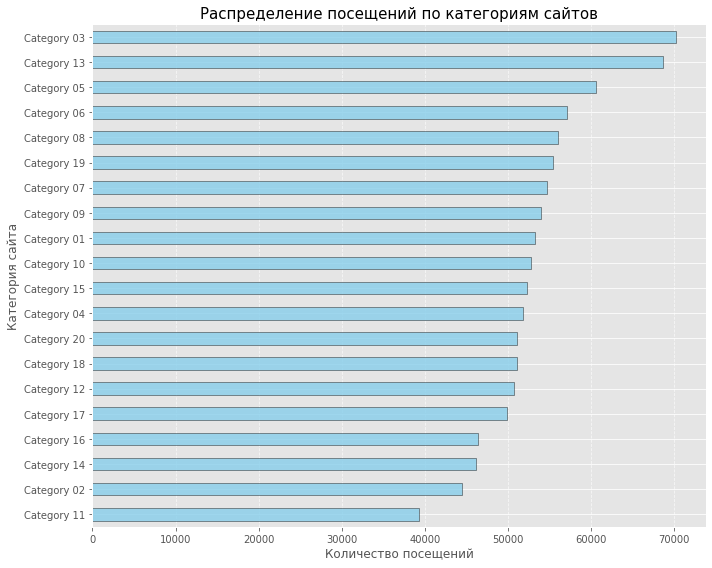

In [16]:
# Смотрим распределение website_category
# -------------------------------------------------------
counts = df_visits['website_category'].value_counts()
percent = df_visits['website_category'].value_counts(normalize=True) * 100

print("Количество:")
print(counts)

print("\nПроцентное соотношение:")
print(percent,'%')
# -------------------------------------------------------

# Визуализируем
# -------------------------------------------------------
# гистограмма распределения 
category_counts = df_visits['website_category'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
category_counts.plot(kind='barh', color='skyblue', edgecolor='black', alpha=0.8)

plt.title('Распределение посещений по категориям сайтов', fontsize=15)
plt.xlabel('Количество посещений')
plt.ylabel('Категория сайта')
plt.grid(axis='x', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()
# -------------------------------------------------------

**Промежуточный вывод:**
- Был проверен датасет df_visits:
- Пропуски отсутсвуют.
- Обнаружено 15750 их требуется удалить
- Замечены все 5826 пользователей, присутствующих в основном датасете, что обеспечит максимальную наполненность признаков для модели.
- Пик активности приходится на день и вечер (суммарно более 72% посещений), ночью активность минимальна (8%).
- В среднем на одного пользователя приходится около 183 визитов в логах.
- Представлено 20 категорий сайтов. Распределение посещений по категориям достаточно сбалансированное, явных аномалий не выявлено.

### Вывод по пункту

**В ходе исследовательского анализа данных было изучено 6 датасетов.**

**Общая структура:**
- Целевой признак (age_category): Наблюдается дисбаланс классов. Самая многочисленная группа - категория 4 (30.3%), самая малочисленная - категория 1 (8.8%).
- В датасетах df_users, df_activity и df_visits обнаружены полные дубликаты (от 1.5% до 4% объема).
- Пропуски в исходных таблицах отсутствуют, но они возникнут при объединении, так как количество уникальных пользователей в дополнительных таблицах (depth, device, usage, activity) меньше, чем в основной.

**Признаки:**
- Целевой признак: age_category - категориальный.
- Категориальные: ads_activity, surf_depth, primary_device, website_category, daytime.
- Числовые: на данном моменте нет.
- Бинарный: cloud_usage.

- Порядковые: ads_activity (5 уровней) и surf_depth (3 уровня).
- Номинальные (Nominal): primary_device (лидер — смартфон, 54%) и website_category (20 категорий).
- Бинарные: cloud_usage (распределение почти 50/50).
- В логах (df_visits) макс. активность приходится на день и вечер.

**План предобработки данных:**

- Удалить полные дубликаты во всех таблицах.
- Агрегация df_visits, нужно сформировать таблицу признаков на основе user_id.
- Объединить все таблицы методом по user_id.
- Проверка датасета: пропуски, кореляция, удаление лишних признаков.
- Разделить данные на обучающую и тестовую выборки (80/20).
- Построить Pipeline для обработки данных.


--------------
## Предобработка данных

### Удаление дубликатов

In [17]:
# df_users
# ----------------------------------------------
print("Размер датасета до удаление дубликатов:", df_users.shape)
df_users = df_users.drop_duplicates().reset_index(drop=True)
print("Размер датасета после удаления:", df_users.shape) # уникальные пользователи
# ----------------------------------------------

# df_activity
# ----------------------------------------------
print("\nРазмер датасета до удаление дубликатов:", df_activity.shape)
df_activity = df_activity.drop_duplicates().reset_index(drop=True)
print("Размер датасета после удаления:", df_activity.shape)
# ----------------------------------------------

# df_visits
# ----------------------------------------------
print("\nРазмер датасета до удаление дубликатов:", df_visits.shape)
df_visits = df_visits.drop_duplicates().reset_index(drop=True)
print("Размер датасета после удаления:", df_visits.shape)
# ----------------------------------------------

Размер датасета до удаление дубликатов: (5913, 2)
Размер датасета после удаления: (5826, 2)

Размер датасета до удаление дубликатов: (5826, 2)
Размер датасета после удаления: (5593, 2)

Размер датасета до удаление дубликатов: (1065745, 5)
Размер датасета после удаления: (1049995, 5)


**Промежуточный вывод:**
- Полные дубликаты удалены.

### Агрегация

In [18]:
# По времени
daytime_agg = df_visits.pivot_table(
    index='user_id', 
    columns='daytime', 
    values='session_id', 
    aggfunc='count', 
    fill_value=0
)

# По категориям сайтов
category_agg = df_visits.pivot_table(
    index='user_id', 
    columns='website_category', 
    values='session_id', 
    aggfunc='count', 
    fill_value=0
)

# Общее количество (для числового признака)
total_visits = df_visits.groupby('user_id')['session_id'].count().to_frame('total_visits')

# Соединение в таблицу
df_visits_agg = daytime_agg.merge(category_agg, on='user_id').merge(total_visits, on='user_id')

print("Размер агрегированной таблицы:", df_visits_agg.shape)
df_visits_agg.head()

Размер агрегированной таблицы: (5826, 25)


,вечер,день,ночь,утро,Category 01,Category 02,Category 03,Category 04,Category 05,Category 06,Category 07,Category 08,Category 09,Category 10,Category 11,Category 12,Category 13,Category 14,Category 15,Category 16,Category 17,Category 18,Category 19,Category 20,total_visits
user_id,,,,,,,,,,,,,,,,,,,,,,,,,
0010-5cf8f6b38a7b6c70a021-009dbcda,226,178,52,90,16,0,34,23,18,29,26,41,13,22,31,43,12,19,15,33,28,43,50,50,546
0013-4ae5f7d127b91a3fb0f8-ba59f141,51,69,16,49,15,11,5,7,15,7,9,18,11,11,13,0,12,7,3,8,12,16,1,4,185
0014-d3032d60979a8d2b3077-f09bdce8,36,45,11,25,1,2,4,7,8,6,5,2,4,6,0,7,20,8,7,2,9,3,12,4,117
001a-eee53e44f848608779b0-78704a67,119,96,31,41,19,13,10,22,10,9,12,13,13,12,14,19,0,28,12,9,13,21,21,17,287
002c-40a064b12e1217e12207-a56eaf3b,145,188,34,123,0,26,35,30,20,19,29,9,29,32,19,42,83,0,22,20,17,6,25,27,490


**Промежуточный вывод:**
- Огромное количество строк в df_visits преобразован в таблицу df_visits_agg (5826 строк). Каждая строка содержит 25 числовых признаков: интенсивность посещений по 4 временным интервалам, активность в 20 тематических категориях сайтов и общий счетчик визитов.

### Соединение в единый датасет

In [19]:
# начинаем с основного датасета
df_full = df_users.copy()

# Список датасетов
dataframes_to_merge = [
    df_visits_agg, 
    df_activity, 
    df_depth, 
    df_device, 
    df_usage,
]

# Последовательно соединяем
for df in dataframes_to_merge:
    df_full = df_full.merge(df, on='user_id', how='left')

# Проверка 
print(f"Размер финального датасета: {df_full.shape}")
print(f"Количество пропусков после объединения:\n{df_full.isna().sum()}")

# -----------
# Дополнительно преименую признаки
df_full = df_full.rename(columns={
    'утро': 'morning',
    'день': 'day',
    'вечер': 'evening',
    'ночь': 'night'
})

# и приведу к единому стилю
df_full.columns = [col.replace(' ', '_').lower() for col in df_full.columns]
# -----------

print("\nНазвания столбцов:")
print(df_full.columns.tolist(), '\n')

# Вывод первых строк 
display(df_full.head())

Размер финального датасета: (5826, 31)
Количество пропусков после объединения:
user_id             0
age_category        0
вечер               0
день                0
ночь                0
утро                0
Category 01         0
Category 02         0
Category 03         0
Category 04         0
Category 05         0
Category 06         0
Category 07         0
Category 08         0
Category 09         0
Category 10         0
Category 11         0
Category 12         0
Category 13         0
Category 14         0
Category 15         0
Category 16         0
Category 17         0
Category 18         0
Category 19         0
Category 20         0
total_visits        0
ads_activity      233
surf_depth        111
primary_device    157
cloud_usage       146
dtype: int64

Названия столбцов:
['user_id', 'age_category', 'evening', 'day', 'night', 'morning', 'category_01', 'category_02', 'category_03', 'category_04', 'category_05', 'category_06', 'category_07', 'category_08', 'category_09', 'cate

,user_id,age_category,evening,day,night,morning,category_01,category_02,category_03,category_04,category_05,category_06,category_07,category_08,category_09,category_10,category_11,category_12,category_13,category_14,category_15,category_16,category_17,category_18,category_19,category_20,total_visits,ads_activity,surf_depth,primary_device,cloud_usage
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,63,67,14,43,12,7,7,11,19,4,0,9,19,5,14,3,6,7,10,8,11,13,14,8,187,NaN,глубоко,смартфон,False
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,55,48,13,25,9,6,14,3,8,5,15,15,6,10,6,6,5,0,9,5,5,4,5,5,141,умеренно,средне,смартфон,False
2,678b-614cd47d854b9d591db2-000b2e50,0,38,29,13,20,1,7,0,11,7,13,0,4,0,1,3,15,12,1,2,3,2,1,11,6,100,умеренно,средне,смартфон,False
3,4ac0-dad169100b4a29b20818-b26ae7c5,4,64,109,18,57,20,1,25,7,27,12,7,16,15,0,16,4,19,5,6,7,16,33,9,3,248,редко,поверхностно,смартфон,True
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0,50,41,9,19,8,5,11,4,6,1,6,8,9,5,5,15,0,10,3,3,6,4,3,7,119,очень редко,поверхностно,смартфон,True


**Промежуточный вывод:**
- Все данные соединены в единый датасет.
- Были обнаружены пропуски, их необходимо обработать.
- Далее необходимо проверить новый датасет на кореляцию с целевой переменной и мультикореляцию, также удалить мусорные признаки.

### Анализ единого датасета (df_full)

Размер датасета: (5826, 31)


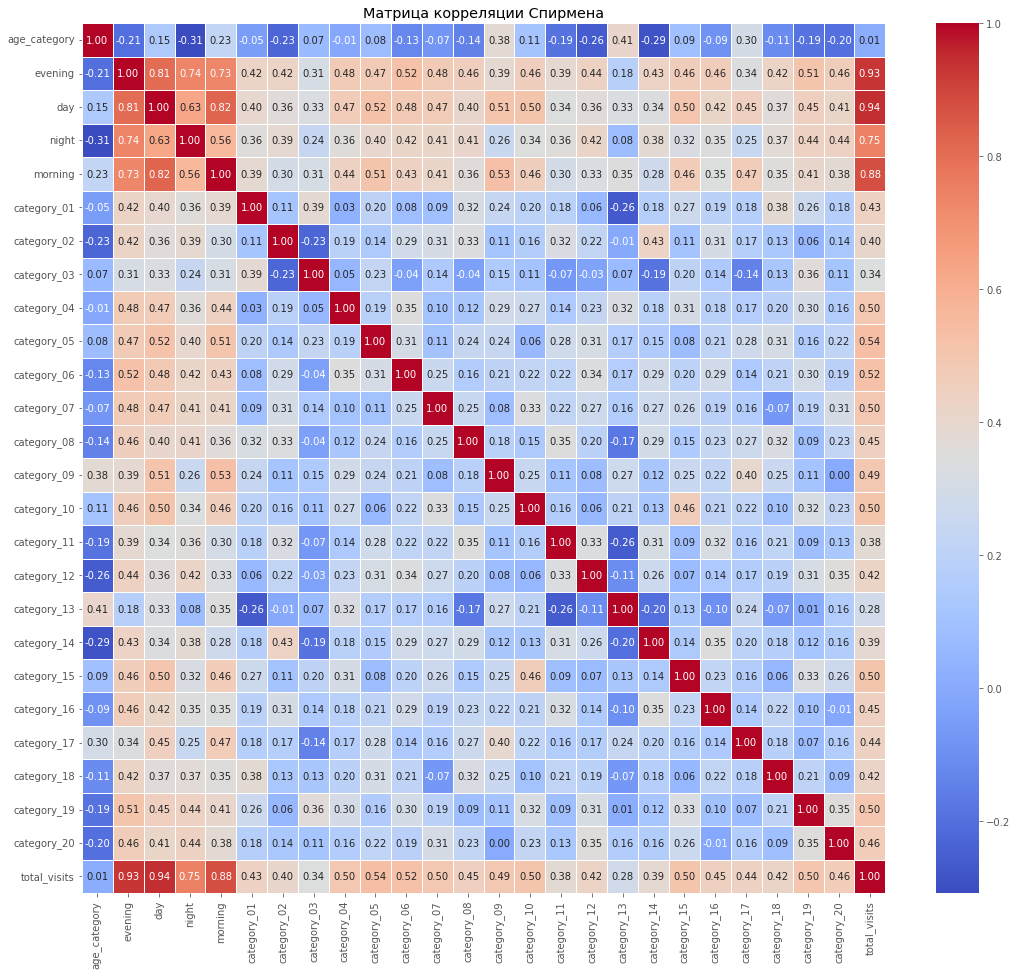

In [20]:
# Контролирую размер датасета
print("Размер датасета:", df_full.shape)

# Проверим кореляцию признаков с целевой переменной и между собой
plt.figure(figsize=(18, 16))
numeric_df = df_full.select_dtypes(include=np.number)   
sns.heatmap(numeric_df.corr(method='spearman'), 
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции Спирмена')
plt.show()

**Обнаружены признаки, которые сильно корелируют между собой (total_visits, day), их а также, мусорные (user_id, и т.д) (константы или име.т очень слабую связь с целевой переменной), необходимо удалить.**

In [21]:
# Удаление карелирующих признаков
cols_to_drop = ['user_id', 'total_visits', 'category_04', 'category_01', 'day']
df_filtred = df_full.drop(columns=cols_to_drop)

# ------------------------
# перепроверяем размер 
print("Размер датасета:", df_filtred.shape)

Размер датасета: (5826, 26)


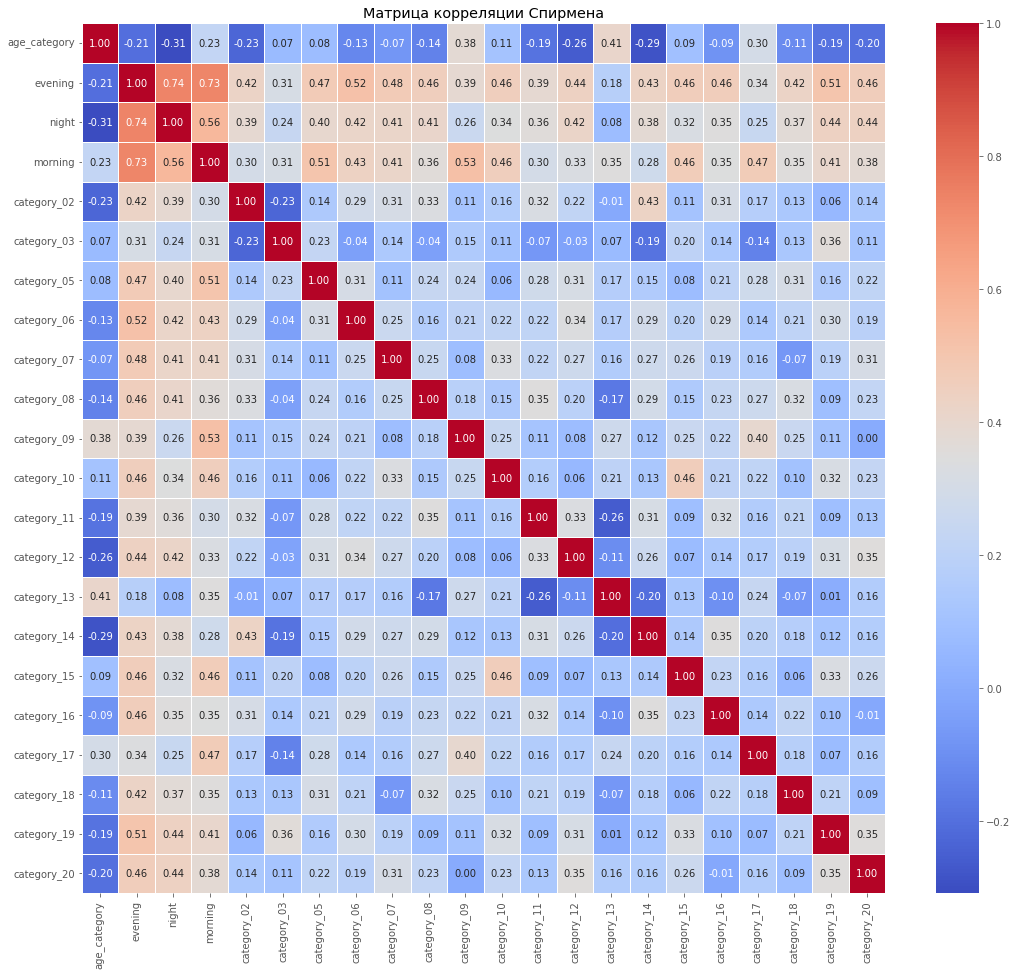

In [22]:
# Проверим кореляцию признаков с целевой переменной и между собой (ещё раз для уверенности)
plt.figure(figsize=(18, 16))
numeric_df = df_filtred.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(method='spearman'), 
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции Спирмена')
plt.show()

**Промежуточный вывод:**
- Удалены признаки total_visits и day, так как они имели высокую корреляцию с другими признаками, что могло привести к нестабильности весов.
- Удален неинформативный признак user_id, так как он является уникальным идентификатором.
- Удалены category_04 и category_01, показавшие очень слабую корреляцию с целевой переменной.
- Наиболее сильную связь с целевой переменной age_category имеют признаки evening и night.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

----------
### Функция для объединения данных

In [23]:
def prepare_features(visits_df, activity_df, depth_df, device_df, usage_df):
    """
    Преобразует сырые датафреймы в единую таблицу признаков, готовую для подачи
    в пайплайн модели.

    Параметры:
    ----------
    visits_df : pd.DataFrame
        Лог посещений сайтов (ds_s13_visits.csv)
    activity_df : pd.DataFrame
        Активность взаимодействия с рекламой (ads_activity.csv)
    depth_df : pd.DataFrame
        Глубина просмотра (surf_depth.csv)
    device_df : pd.DataFrame
        Основное устройство (primary_device.csv)
    usage_df : pd.DataFrame
        Использование облачных технологий (cloud_usage.csv)

    Возвращает:
    ----------
    pd.DataFrame
        Датафрейм с признаками для каждого пользователя (столбец user_id удалён).
        Столбцы соответствуют тем, что использовались при обучении модели.
    """
    # Удаление полных дубликатов
    visits_df = visits_df.drop_duplicates().reset_index(drop=True)
    activity_df = activity_df.drop_duplicates().reset_index(drop=True)
    depth_df = depth_df.drop_duplicates().reset_index(drop=True)
    device_df = device_df.drop_duplicates().reset_index(drop=True)
    usage_df = usage_df.drop_duplicates().reset_index(drop=True)

    # Агрегация по времени суток
    daytime_agg = visits_df.pivot_table(
        index='user_id', columns='daytime', values='session_id', aggfunc='count', fill_value=0
    )
    # берем названия времен суток
    if isinstance(daytime_agg.columns, pd.MultiIndex):
        daytime_agg.columns = daytime_agg.columns.get_level_values(1)
    
    # Теперь reindex сработает корректно
    expected_times = ['утро', 'день', 'вечер', 'ночь']
    daytime_agg = daytime_agg.reindex(columns=expected_times, fill_value=0)

    # Агрегация по категориям сайтов
    category_agg = visits_df.pivot_table(
        index='user_id', columns='website_category', values='session_id', aggfunc='count', fill_value=0
    )
    if isinstance(category_agg.columns, pd.MultiIndex):
        category_agg.columns = category_agg.columns.get_level_values(1)
        
    expected_cats = [f'category_{i:02d}' for i in range(1, 21)]
    category_agg = category_agg.reindex(columns=expected_cats, fill_value=0)

    # Общее количество визитов 
    total_visits = visits_df.groupby('user_id')['session_id'].count().to_frame('total_visits')

    # Объединяем агрегации
    visits_agg = daytime_agg.join(category_agg).join(total_visits)

    # Последовательное объединение
    df_full = activity_df.merge(visits_agg, on='user_id', how='right')
    df_full = df_full.merge(depth_df, on='user_id', how='left')
    df_full = df_full.merge(device_df, on='user_id', how='left')
    df_full = df_full.merge(usage_df, on='user_id', how='left')

    # Переименование столбцов
    df_full = df_full.rename(columns={
        'утро': 'morning', 'день': 'day', 'вечер': 'evening', 'ночь': 'night'
    })
    df_full.columns = [col.replace(' ', '_').lower() for col in df_full.columns]

    # Удаление лишнего
    cols_to_drop = ['user_id', 'total_visits', 'category_04', 'category_01', 'day']
    df_final = df_full.drop(columns=[c for c in cols_to_drop if c in df_full.columns])

    return df_final

print('Функция создана')

Функция создана


**Промежуточный вывод:**
- Добавлена функция prepare_features(), которая сохраняет все шаги предобработки: удаление дубликатов, агрегацию логов посещений, объединение таблиц и удаление неинформативных признаков.
- Она сохранена для использования при внедрении модели на новых "сырых" данных.
-----------

### Разделение на выборки

In [24]:
# Для удобства выведу себе информацию
print("\nНазвания столбцов:")
print(df_filtred.columns.tolist(), '\n')

# Вывод первых строк 
df_filtred.head()


Названия столбцов:
['age_category', 'evening', 'night', 'morning', 'category_02', 'category_03', 'category_05', 'category_06', 'category_07', 'category_08', 'category_09', 'category_10', 'category_11', 'category_12', 'category_13', 'category_14', 'category_15', 'category_16', 'category_17', 'category_18', 'category_19', 'category_20', 'ads_activity', 'surf_depth', 'primary_device', 'cloud_usage'] 



,age_category,evening,night,morning,category_02,category_03,category_05,category_06,category_07,category_08,category_09,category_10,category_11,category_12,category_13,category_14,category_15,category_16,category_17,category_18,category_19,category_20,ads_activity,surf_depth,primary_device,cloud_usage
0,4,63,14,43,7,7,19,4,0,9,19,5,14,3,6,7,10,8,11,13,14,8,NaN,глубоко,смартфон,False
1,2,55,13,25,6,14,8,5,15,15,6,10,6,6,5,0,9,5,5,4,5,5,умеренно,средне,смартфон,False
2,0,38,13,20,7,0,7,13,0,4,0,1,3,15,12,1,2,3,2,1,11,6,умеренно,средне,смартфон,False
3,4,64,18,57,1,25,27,12,7,16,15,0,16,4,19,5,6,7,16,33,9,3,редко,поверхностно,смартфон,True
4,0,50,9,19,5,11,6,1,6,8,9,5,5,15,0,10,3,3,6,4,3,7,очень редко,поверхностно,смартфон,True


In [25]:
# -----------------------------------------------------------------
# Делим признаки на категориальные, числовые и те, что требуют "особой" обработки

# делим на категориальные признаки 
cat_columns = ['cloud_usage', 'primary_device']

# числовые
num_columns = ['morning', 'evening', 'night', 'category_02', 'category_03', 'category_05', 'category_06', 
               'category_07', 'category_08', 'category_09', 'category_10', 'category_11', 'category_12', 
               'category_13', 'category_14', 'category_15', 'category_16', 'category_17', 'category_18', 
               'category_19', 'category_20']

# категориальный, но со своей обработкой (так, как в признаке была заметная ирархия, пришлось дополнитьльно искать методы)
spec_columns = ['ads_activity', 'surf_depth']

# --------------------------

# разделяем признаки и целевую переменную
X = df_filtred.drop(columns=["age_category"])
y = df_filtred["age_category"]
# -----------------------------------------------------------------

# -----------------------------------------------------------------
# делаем выборку
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    stratify=y,
    random_state = RANDOM_STATE
)
# -----------------------------------------------------------------

# проверим размеры
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Доля целевого класса в train: {y_train.mean():.3f}")
print(f"Доля целевого класса в test: {y_test.mean():.3f}")

Размер обучающей выборки: (4660, 25)
Размер тестовой выборки: (1166, 25)
Доля целевого класса в train: 2.441
Доля целевого класса в test: 2.439


### Обработка 

In [26]:
# Создадим пайплайны для предобработки

# ----------------------------
# пайплайн для числовых признаков
pipeline_num = Pipeline([
    ('imputer_num', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])
# ----------------------------

# ----------------------------
# пайплайн для категориальных признаков
pipeline_cat = Pipeline([
    ('imputer_cat', SimpleImputer(strategy = 'most_frequent')),
    ('target_encoder', OneHotEncoder(drop='first')) # удаляет первый столбец
])
# ----------------------------

# ----------------------------
# пайплайн для "специальных" признаков
pipeline_spec = Pipeline([
    ('imputer_spec', SimpleImputer(strategy = 'most_frequent')),
    ('ordinal_encoder', OrdinalEncoder(categories=[['очень редко', 'редко', 'умеренно', 'часто', 'очень часто'], 
                                                   ['поверхностно', 'средне', 'глубоко']])) 
])
# ----------------------------

# ----------------------------
# строим оптимуса (трансформер)
processor = ColumnTransformer([
    ('num', pipeline_num, num_columns),
    ('cat', pipeline_cat, cat_columns),
    ('spec', pipeline_spec, spec_columns),
])
# ----------------------------

# ----------------------------
# применяем к train, чтобы избежать утечки
X_train_transformed = processor.fit_transform(X_train, y_train)

# названия колонок
feature_names = processor.get_feature_names_out()

# делаем датафреймом для удобстава
X_train_final = pd.DataFrame(X_train_transformed, columns=feature_names)
# ----------------------------

# проверяем размер
print('\n Размер:', X_train_final.shape)

X_train_final.head()


 Размер: (4660, 27)


,num__morning,num__evening,num__night,num__category_02,num__category_03,num__category_05,num__category_06,num__category_07,num__category_08,num__category_09,num__category_10,num__category_11,num__category_12,num__category_13,num__category_14,num__category_15,num__category_16,num__category_17,num__category_18,num__category_19,num__category_20,cat__cloud_usage_True,cat__primary_device_ноутбук,cat__primary_device_планшет,cat__primary_device_смартфон,spec__ads_activity,spec__surf_depth
0,0.194,0.806,-0.426,-0.878,1.450,0.821,0.814,0.413,1.315,-0.648,0.013,0.584,-0.824,-0.984,-0.282,-0.276,1.426,0.234,-0.229,-0.207,-0.407,1.000,0.000,0.000,1.000,2.000,1.000
1,1.908,1.952,2.081,1.680,0.730,1.688,1.735,1.468,2.148,0.442,0.911,3.535,1.985,-0.984,3.239,1.690,0.957,1.452,0.342,1.756,0.492,0.000,0.000,0.000,0.000,2.000,0.000
2,5.398,5.321,4.588,8.394,0.820,2.554,3.578,4.784,2.703,0.908,-1.335,1.625,6.569,-0.899,7.679,0.783,1.896,0.539,-1.228,6.739,5.435,1.000,1.000,0.000,0.000,2.000,0.000
3,-0.541,0.077,1.385,0.721,-0.262,-0.189,-0.722,1.166,0.482,-1.115,0.013,1.104,0.802,-0.984,0.177,-0.125,0.019,-0.527,-0.372,0.548,-0.557,1.000,1.000,0.000,0.000,2.000,1.000
4,-0.234,-0.999,-0.008,0.881,-1.073,-0.189,-0.722,-0.341,-0.211,-0.181,0.462,-0.111,0.654,-0.303,0.024,-0.729,-0.294,-0.831,-0.657,-1.264,-1.006,0.000,1.000,0.000,0.000,0.000,2.000


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### Вывод по пункту

**Была проведена полная предобработка данных**

- Удалены полные дубликаты в основных таблицах. Общее количество уникальных пользователей после чистки составило 5826 человек.
- Проведена агрегация логов посещений (df_visits). Сформированы числовые признаки, описывающих активность пользователей: интенсивность посещений по времени суток и интересы к 20 тематическим категориям сайтов.
- Все датасеты соеденены в единый df_full. 
- На основе корреляционного анализа Спирмена удалены признаки с сильной мультиколлинеарностью (total_visits, day) и «мусорные» с низкой кореляцией с целевой переменной (user_id, category_01, category_04). 
- Данные разделены на обучающую и тестовую выборки в пропорции 80/20 с применением стратификации.

**Обработчик данных:**
- Заполняет пропуски (медианой для чисел и модой для категорий).
- Масштабирует числовые признаки (StandardScaler).
- Кодирует категориальные признаки (OneHotEncoder) и сохраняет порядок в других признаках (OrdinalEncoder).

-------------------
## Обучение и оценка базовой модели

### Обучение моделей

**Выбор:**
- DummyClassifier нужен, так как он позволяет доказать, что любая обученная модель работает, а не угадывает результат на основе частоты классов.

**Logistic Regression (OvR и Multinomial):**
- Были выбраны, чтобы проверить, можно ли разделить возрастные категории простыми гиперплоскостями (линейная связь).

**SVM с ядром RBF:**
- Эта модель выбрана для обработки нелинейных связей. 
- Сатегия OvO выбрана, так как этот алгоритм наиболее эффективно работает при попарном сравнении классов.

In [27]:
# ------------------------------------------------------------------------
# Определяем набор метрик
scoring_metrics = {
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

# Настройка кроссвалидвции
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# ------------------------------------------------------------------------


# ------------------------------------------------------------------------
# Думми модель 
pipeline_dummy = Pipeline(steps=[
    ('classifier', DummyClassifier(strategy="most_frequent"))
])

results_dummy = cross_validate(
    estimator=pipeline_dummy,              
    X=X_train, y=y_train,                                        
    scoring=scoring_metrics,  
    cv=cv_strat, 
    n_jobs=-1
)
# ------------------------------------------------------------------------


# ------------------------------------------------------------------------
# Логистическая регрессия (OvR)
pipeline_log = Pipeline([
    ('preprocessor', processor), 
    ('classifier', OneVsRestClassifier(LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced'))) 
])

results_base_log = cross_validate(
    estimator=pipeline_log,              
    X=X_train, y=y_train,                                   
    scoring=scoring_metrics,  
    cv=cv_strat,                                          
    n_jobs=-1                                
)
# ------------------------------------------------------------------------


# ------------------------------------------------------------------------
# SVM модель (OvO)
# Использую с нелинейным ядром 'rbf'
pipeline_svm = Pipeline([
    ('preprocessor', processor), 
    ('classifier', OneVsOneClassifier(SVC(random_state=RANDOM_STATE, kernel='rbf', class_weight='balanced'))) 
])

results_base_svc = cross_validate(
    estimator=pipeline_svm,              
    X=X_train, y=y_train,                                   
    scoring=scoring_metrics,  
    cv=cv_strat,                                          
    n_jobs=-1                                
)
# ------------------------------------------------------------------------


# ------------------------------------------------------------------------
# Логистическая регрессия (multinomial)
pipeline_log_multi = Pipeline([
    ('preprocessor', processor), 
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, 
                                      multi_class='multinomial', 
                                      solver='lbfgs', 
                                      class_weight='balanced')) 
])

results_base_log_multi = cross_validate(
    estimator=pipeline_log_multi,              
    X=X_train, y=y_train,                                   
    scoring=scoring_metrics,  
    cv=cv_strat,                                          
    n_jobs=-1                                
)
# ------------------------------------------------------------------------

print('Модели обучены!')

Модели обучены!


### Оценка базовыйх моделей

In [28]:
# ------------------------------------------------------------------------
# Функция для вывода метрик
def print_results(name, results):
    print(f"-{name}-")
    print(f"F1-macro: {results['test_f1_macro'].mean():.3f}")
    print(f"Precision-macro: {results['test_precision_macro'].mean():.3f}")
    print(f"Recall-macro: {results['test_recall_macro'].mean():.3f}\n")

print_results("Dummy", results_dummy)
print_results("Logistic Regression (OvR)", results_base_log)
print_results("SVM (OvO)", results_base_svc)
print_results("Logistic Regression (Multinomial)", results_base_log_multi)
# ------------------------------------------------------------------------

-Dummy-
F1-macro: 0.093
Precision-macro: 0.061
Recall-macro: 0.200

-Logistic Regression (OvR)-
F1-macro: 0.798
Precision-macro: 0.795
Recall-macro: 0.804

-SVM (OvO)-
F1-macro: 0.862
Precision-macro: 0.856
Recall-macro: 0.872

-Logistic Regression (Multinomial)-
F1-macro: 0.808
Precision-macro: 0.803
Recall-macro: 0.820



### Вывод по разделу


**Были обучены 4 базовых модели и выведены их метрики**

- Baseline (DummyClassifier): Показал  низкое качество (0,093).
- Логистическая регрессия: Multinomial (0,808) оказался эффективнее One-vs-Rest (0,798).
- SVM (OvO) с ядром RBF: Продемонстрировал лучший результат (0,862), это подтверждает наличие нелинейных зависимостей в поведении пользователей. 

**В качестве приоритетной модели (на данный момент) выбрана SVM (OvO).**

---------------
## Создание и отбор признаков

**Будет проверено несколько способов создания признаков и выбран один, самы эффективный**

### Применение фильтрационных методов

In [29]:
# проверим кореляцию признаков, если есть мультикореируемые или те, 
# что вообще не корелируют с целевой переменной, то необходимо их удалить

# ----------------------------
# Mutual info
mi_scores = mutual_info_classif(X_train_final, 
                                y_train, 
                                random_state=RANDOM_STATE)

# для красивого вывода
mi_results = pd.Series(mi_scores, index=X_train_final.select_dtypes(include=[np.number]).columns)
mi_results = mi_results.sort_values(ascending=False)

print("Топ признаков по корреляции с click:")
print(mi_results.head(20))
# ----------------------------

Топ признаков по корреляции с click:
num__category_13     0.156
num__category_16     0.105
num__category_09     0.103
num__category_12     0.100
num__category_18     0.086
num__category_02     0.086
num__category_20     0.082
num__category_08     0.071
num__category_17     0.068
num__category_07     0.064
num__category_03     0.058
num__category_11     0.057
spec__ads_activity   0.055
num__category_14     0.054
num__category_10     0.052
num__category_15     0.048
num__category_19     0.045
num__morning         0.042
num__night           0.038
num__category_06     0.037
dtype: float64


In [30]:
# Удалим "лишние" и проверим размер
# ----------------------------
# Зададим порог 
threshold_mi = 0.02

# Отбираем признаки
features_to_keep = mi_results[mi_results > threshold_mi].index.tolist()

# Сокращаем датасет
X_train_fs_filtered = X_train_final[features_to_keep]

print(f"Размер до: {X_train_final.shape}")
print(f"Размер после фильтрации по MI (порог {threshold_mi}): {X_train_fs_filtered.shape}")
print(f"Удаленные признаки: {set(X_train_final.columns) - set(features_to_keep)}")
# ----------------------------

Размер до: (4660, 27)
Размер после фильтрации по MI (порог 0.02): (4660, 23)
Удаленные признаки: {'cat__primary_device_планшет', 'cat__primary_device_смартфон', 'cat__primary_device_ноутбук', 'spec__surf_depth'}


**Промежуточный вывод:**
- Удалено 4 признака, чей показатель информационной ценности был ниже порога.
- Из модели исключены данные о типах устройств (ноутбук, планшет, смартфон) и глубине просмотра страниц. Это говорит о том, что для предсказания возраста технические характеристики сессии менее важны, чем тематика посещаемых ресурсов.

### Применение методов-обёрток

In [31]:
# я буду использовать RFE
rfe_selector = RFE(
    estimator=LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE),
    n_features_to_select=15, # Сколько лучших признаков оставить
    step=1
)

# Обучаем RFE на твоем трансформированном X_train
rfe_selector.fit(X_train_final, y_train)

# Получаем список признаков, которые прошли "отбор"
selected_features_rfe = X_train_final.columns[rfe_selector.support_]

print("Признаки, отобранные методом-оберткой:")
print(selected_features_rfe)
print('\nКоличество:', selected_features_rfe.shape[0])

Признаки, отобранные методом-оберткой:
Index(['num__morning', 'num__evening', 'num__night', 'num__category_03',
       'num__category_07', 'num__category_08', 'num__category_09',
       'num__category_10', 'num__category_12', 'num__category_13',
       'num__category_15', 'num__category_16', 'num__category_17',
       'num__category_18', 'num__category_20'],
      dtype='object')

Количество: 15


**Промежуточный вывод:**
- Модель сфокусировалась на временных периодах (morning, evening, night) и ключевых тематических категориях (например, category_13, 16, 09).
- Удаление почти половины признаков (с 27 до 15) теоретически должно снизить риск переобучения и уменьшить "шум", однако необходимо проверить, не приведет ли это к потере точности у нелинейного лидера — SVM.

### Создание новых признаков

In [32]:
# РРРУбрика - Эксперименты

# Создадим копию для экспериментиков
X_train_engineered = X_train_final.copy()

# Считаем общее количество визитов по категориям для каждой строки
cat_columns = [col for col in X_train_final.columns if 'num__category_' in col]
total_cat_visits = X_train_final[cat_columns].sum(axis=1)

# пропорции
for col in cat_columns:
    new_col_name = col + '_share'
    # чтобы не было деления на 0, добавляем мальенкое число (как с Log)
    X_train_engineered[new_col_name] = X_train_final[col] / (total_cat_visits + 1e-9)

# Ну и доли по времени
time_columns = ['num__morning', 'num__evening', 'num__night'] 
total_time_visits = X_train_final[time_columns].sum(axis=1)

for col in time_columns:
    X_train_engineered[col + '_share'] = X_train_final[col] / (total_time_visits + 1e-9)

# вывод
print(f"Количество признаков: {X_train_engineered.shape[1]}")

Количество признаков: 48


**Промежуточный вывод:**
- Добавлены показатели для каждой категории сайтов и временных интервалов (48 признаков).

### Сравнение методов

In [33]:
# ------------------------------------------------------------------------
# Функция для проверки
def evaluate_feature_set(name, X, y):
    # Оцениваем лидера — SVM (OvO)
    res = cross_validate(
        estimator=OneVsOneClassifier(SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE)),
        X=X, y=y,
        scoring=scoring_metrics,
        cv=cv_strat,
        n_jobs=-1
    )
    
    print(f"-{name}-")
    print(f"F1-macro: {res['test_f1_macro'].mean():.3f}")
    print(f"Precision-macro: {res['test_precision_macro'].mean():.3f}")
    print(f"Recall-macro: {res['test_recall_macro'].mean():.3f}\n")
    return res

# -----------------------
# Сравнение
# MI
results_mi = evaluate_feature_set("(MI)", X_train_fs_filtered, y_train)

# RFE 
results_rfe = evaluate_feature_set("(RFE)", X_train_final[selected_features_rfe], y_train)

# Новые признаки
results_eng = evaluate_feature_set("Новые признаки", X_train_engineered, y_train)
# ------------------------------------------------------------------------

-(MI)-
F1-macro: 0.862
Precision-macro: 0.856
Recall-macro: 0.870

-(RFE)-
F1-macro: 0.817
Precision-macro: 0.813
Recall-macro: 0.826

-Новые признаки-
F1-macro: 0.756
Precision-macro: 0.762
Recall-macro: 0.777



### Доп. проверка других моделей

In [34]:
# ------------------------------------------------------------------------
# Проверка Logistic Regression (OvR) на признаках MI
results_log_ovr_mi = cross_validate(
    estimator=OneVsRestClassifier(LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=1000)),
    X=X_train_fs_filtered, 
    y=y_train,
    scoring=scoring_metrics,
    cv=cv_strat,
    n_jobs=-1
)

# ------------------------------------------------------------------------

# ------------------------------------------------------------------------
# Проверка Logistic Regression (Multinomial) на признаках MI
results_log_multi_mi = cross_validate(
    estimator=LogisticRegression(random_state=RANDOM_STATE, 
                                 multi_class='multinomial', 
                                 solver='lbfgs', 
                                 class_weight='balanced'),
    X=X_train_fs_filtered, 
    y=y_train,
    scoring=scoring_metrics,
    cv=cv_strat,
    n_jobs=-1
)
# ------------------------------------------------------------------------


# Вывод результатов
print_results("Logistic Regression (OvR) на MI-признаках", results_log_ovr_mi)
print_results("Logistic Regression (Multinomial) на MI-признаках", results_log_multi_mi)
# ------------------------------------------------------------------------

-Logistic Regression (OvR) на MI-признаках-
F1-macro: 0.799
Precision-macro: 0.796
Recall-macro: 0.805

-Logistic Regression (Multinomial) на MI-признаках-
F1-macro: 0.808
Precision-macro: 0.803
Recall-macro: 0.820



**Промежуточный вывод:**
- SVM сохраняет лидерство, следовательно она остаётся главной для подбора гиперпараметров.

### Вывод по разделу

**Были проверены три подхода подготовки данных для нашей лучшей базовой модели — SVM (OvO).**

- Фильтрация по Mutual Information (MI): исключены 4 признака с низкой кореляцией (в основном технические параметры сессии, такие как тип устройства и глубина сёрфинга) позволило сохранить качество предсказания на исходном уровне (F1-macro = 0.862) и увеличило. Это лучший результат, который показывает, что мы избавились от "шума", а обобщающая способность модели осталась высокой.

- Метод-обертка RFE: сократыил до 15 признаков, что привело к заметному падению качества (F1-macro снизилась до 0.817). 

- Генерация новых признаков: это увеличило размер до 48 признаков, однако привело к уменьшению метрик (F1-macro упала до 0.756). Вероятнее всего, из-за мультиколлинеарности.

**Для финального обучения и подбора гиперпараметров будет использоваться набор данных, полученный после фильтрации методом Mutual Information (23 признака), метрики не изменились, но были убраны "шумные" признаки.**

---------------
## Подбор гиперпараметров моделей

### Pipeline с моделями

In [35]:
# ------------------------------------------------------------------------
# Финальный пипелине SVM (OvO)
full_pipeline_svc = Pipeline(steps=[
    ('preprocessor', processor), 
    ('selector', SelectKBest(score_func=mutual_info_classif, k=23)), 
    ('classifier', OneVsOneClassifier(SVC(random_state=RANDOM_STATE, class_weight='balanced')))
])
# ------------------------------------------------------------------------

# ------------------------------------------------------------------------
# OVR
full_pipeline_ovr = Pipeline(steps=[
    ('preprocessor', processor),
    ('selector', SelectKBest(score_func=mutual_info_classif, k=23)),
    ('classifier', OneVsRestClassifier(
        LogisticRegression(class_weight='balanced', 
                           random_state=RANDOM_STATE, 
                           max_iter=1000)
    ))
])
# ------------------------------------------------------------------------

# ------------------------------------------------------------------------
# Logreg 
full_pipeline_log = Pipeline(steps=[
    ('preprocessor', processor),
    ('selector', SelectKBest(score_func=mutual_info_classif, k=23)),
    ('classifier', LogisticRegression(multi_class='multinomial', 
                                      class_weight='balanced', 
                                      random_state=RANDOM_STATE))
])
# ------------------------------------------------------------------------

### Подбор гиперпараметров к модели SVM

In [36]:
# Сетка 
param_grid_svc = {
    'classifier__estimator__C': [0.1, 1, 10, 100],
    'classifier__estimator__gamma': ['scale', 'auto', 0.1, 1],
    'classifier__estimator__kernel': ['linear', 'poly', 'rbf']
}

# Настройка
grid_search_svc = GridSearchCV(
    estimator=full_pipeline_svc,
    param_grid=param_grid_svc,
    scoring='f1_macro',
    cv=cv_strat,
    n_jobs=-1,
    verbose=1
)

print("Подбор:")
grid_search_svc.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {grid_search_svc.best_params_}")
print(f"Лучший F1-macro SVM: {grid_search_svc.best_score_:.3f}")

Подбор:
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Лучшие параметры SVM: {'classifier__estimator__C': 10, 'classifier__estimator__gamma': 'scale', 'classifier__estimator__kernel': 'rbf'}
Лучший F1-macro SVM: 0.876


**Метрики чуть-чуть увеличились**

### Подбор гиперпараметров к OvR

In [37]:
param_grid_ovr = {
    'classifier__estimator__C': [0.1, 1, 10, 100],
    'classifier__estimator__solver': ['lbfgs', 'saga']
}

grid_search_ovr = GridSearchCV(
    estimator=full_pipeline_ovr,
    param_grid=param_grid_ovr,
    scoring='f1_macro',
    cv=cv_strat,
    n_jobs=-1,
    verbose=1
)

print("Подбор:")
grid_search_ovr.fit(X_train, y_train)

print(f"Лучшие параметры OvR: {grid_search_ovr.best_params_}")
print(f"Лучший F1-macro OvR: {grid_search_ovr.best_score_:.3f}")

Подбор:
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Лучшие параметры OvR: {'classifier__estimator__C': 100, 'classifier__estimator__solver': 'saga'}
Лучший F1-macro OvR: 0.801


### Подбор гиперпараметров к Multinomial

In [38]:
param_grid_log = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__solver': ['lbfgs', 'saga']
}

grid_search_log = GridSearchCV(
    estimator=full_pipeline_log,
    param_grid=param_grid_log,
    scoring='f1_macro',
    cv=cv_strat,
    n_jobs=-1,
    verbose=1
)

print("Подбор:")
grid_search_log.fit(X_train, y_train)

print(f"Лучшие параметры Multinomial: {grid_search_log.best_params_}")
print(f"Лучший F1-macro Multinomial: {grid_search_log.best_score_:.3f}")

Подбор:
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Лучшие параметры Multinomial: {'classifier__C': 100, 'classifier__solver': 'saga'}
Лучший F1-macro Multinomial: 0.807


### Сравнение метрик

In [39]:
# Установка опции для отображения максимальной ширины столбца (новинка!)
pd.set_option('display.max_colwidth', None)

# В единую таблиуцу
final_comparison = pd.DataFrame({
    'Модель': ['Dummy (Baseline)', 'SVM (OvO)', 'LogReg (OvR)', 'LogReg (Multinomial)'],
    'F1-macro (CV)': [
        results_dummy['test_f1_macro'].mean(), 
        grid_search_svc.best_score_,
        grid_search_ovr.best_score_,
        grid_search_log.best_score_
    ],
    'Лучшие параметры': [
        'strategy="most_frequent"',
        str(grid_search_svc.best_params_),
        str(grid_search_ovr.best_params_),
        str(grid_search_log.best_params_)
    ]
})

# Сортируем по убыванию 
final_comparison = final_comparison.sort_values(by='F1-macro (CV)', ascending=False).reset_index(drop=True)

print("\nИтоговое сравнение на кросс-валидации:")
display(final_comparison)


Итоговое сравнение на кросс-валидации:


,Модель,F1-macro (CV),Лучшие параметры
0,SVM (OvO),0.876,"{'classifier__estimator__C': 10, 'classifier__estimator__gamma': 'scale', 'classifier__estimator__kernel': 'rbf'}"
1,LogReg (Multinomial),0.807,"{'classifier__C': 100, 'classifier__solver': 'saga'}"
2,LogReg (OvR),0.801,"{'classifier__estimator__C': 100, 'classifier__estimator__solver': 'saga'}"
3,Dummy (Baseline),0.093,"strategy=""most_frequent"""


**Итоговая модель выбрана - SVM(OvO)**

### Обучение финальной модели и её метрики

Метрики финальной модели на тестовой выборке:
F1-macro:  0.867
Precision: 0.864
Recall:    0.870


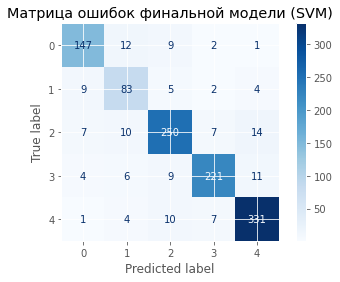

In [40]:
# Выбираем лучший пайплайн из GridSearchCV
final_model = grid_search_svc.best_estimator_

# Получаем предсказания на тестовой выборке
y_pred = final_model.predict(X_test)

# Расчет метрик
f1_test = f1_score(y_test, y_pred, average='macro')
precision_test = precision_score(y_test, y_pred, average='macro')
recall_test = recall_score(y_test, y_pred, average='macro')

print("Метрики финальной модели на тестовой выборке:")
print(f"F1-macro:  {f1_test:.3f}")
print(f"Precision: {precision_test:.3f}")
print(f"Recall:    {recall_test:.3f}")

# Матрица ошибок
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test, cmap='Blues')
plt.title("Матрица ошибок финальной модели (SVM)")
plt.show()

**Промежуточный вывод:**
- Матрица ошибок подтверждает высокую предсказательную способность модели
- Основная масса предсказаний сосредоточена на главной диагонали. Особенно уверенно модель определяет самую многочисленную группу (4).
- По ошибкам, модель чаще всего выбирает смежную возрастную категорию. Это указывает на то, что модель заметила внутреннюю логику.


### Анализ весов 

Топ-10 наиболее важных признаков:


,Feature,Importance
13,num__category_13,0.144
9,num__category_09,0.096
16,num__category_16,0.094
12,num__category_12,0.090
17,num__category_17,0.077
18,num__category_18,0.076
7,num__category_07,0.070
4,num__category_03,0.070
10,num__category_10,0.067
20,num__category_20,0.062


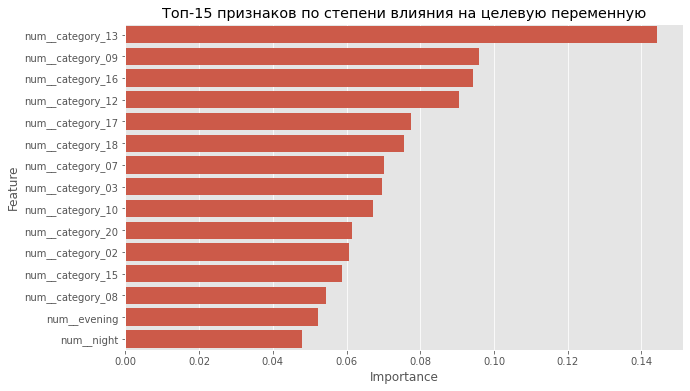

In [41]:
# Извлекаем селектор
selector = final_model.named_steps['selector']

# Получаем веса 
mi_scores = selector.scores_

# криво-косо получаю имена
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

# Таблица
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': mi_scores
}).sort_values(by='Importance', ascending=False)

print("Топ-10 наиболее важных признаков:")
display(feature_importance.head(10))

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15))
plt.title("Топ-15 признаков по степени влияния на целевую переменную")
plt.show()

**Промежуточный вывод:**
- В топ вошли исключительно трансформированные числовые представления категорий (num__category). Это подтверждает, что поведение пользователей в конкретных разделах или типах контента является наиболее информативным.
- Наибольший вклад вносит category_13 (вес 0.140), за ней следуют category_09 и category_16. Эти категории можно считать основными.

### Вывод по разделу

**Был проведён подбор гиперпараметров и оценки моделей**
- Были протестированы три модели. 
- SVM с OvO-стратегией и ядром rbf показал лучшие метрики, чем линейные модели (F1-macro 0.869 против 0.809 у лучшей логистической регрессии).
- Оптимальными параметрами для SVM стали C=10 и gamma='scale', что позволило модели эффективно разделить классы, сохранив при этом обобщающую способность.
- Финальная проверка на отложенной выборке подтвердила стабильность решения. Признаков переобучения нет, а матрица ошибок показывает, что предсказания логичны.
- Главную роль в предсказании имеют признаки num__category (13, 09 и 16).

**Разработанный пайплайн полностью соответствует требованиям, готов к сохранению и использования в продакшене.**

---------------
## Подготовка артефактов модели для внедрения

### Сохранение модели 

In [42]:
# Создаём папку
os.makedirs('model', exist_ok=True)

# Сохраняем 
preprocessor = final_model.named_steps['preprocessor']
selector = final_model.named_steps['selector']
classifier = final_model.named_steps['classifier']

# Получаем список признаков, которые остались после MI
all_transformed_features = preprocessor.get_feature_names_out()
selected_features = all_transformed_features[selector.get_support()].tolist()

# Сохраняем в файлы
joblib.dump(preprocessor, 'model/preprocessor.pkl')
joblib.dump(selector, 'model/selector.pkl') # Сохраняем селектор отдельно
joblib.dump(classifier, 'model/model.pkl') 
joblib.dump(selected_features, 'model/selected_features.pkl')
joblib.dump(prepare_features, 'model/prepare_features.pkl') # Сохраняем саму функцию подготовки признаков (новинка!)

print("Все компоненты сохранены в папку 'model'")

Все компоненты сохранены в папку 'model'


### Проверка работоспособности

In [43]:
# Загружаем артефакты (главное болты не забыть, и в аномалию не попасть)  =3
loaded_preprocessor = joblib.load('model/preprocessor.pkl')
loaded_selector = joblib.load('model/selector.pkl')
loaded_model = joblib.load('model/model.pkl')
loaded_features = joblib.load('model/selected_features.pkl')

# Берём рандом значения
sample_data = X_test.sample(5, random_state=RANDOM_STATE)

# Препроцессинг
data_preprocessed = loaded_preprocessor.transform(sample_data)

# делаю датафреймом для своих признаков
data_preprocessed_df = pd.DataFrame(
    data_preprocessed, 
    columns=loaded_preprocessor.get_feature_names_out(),
    index=sample_data.index
)
data_filtered = data_preprocessed_df[loaded_features]

# Получение предсказаний
original_preds = final_model.predict(sample_data)

# Загруженные компоненты
loaded_preds = loaded_model.predict(data_filtered)

# Выводы для сравнения
print("Предсказания оригинального Pipeline:", original_preds[:5])
print("Предсказания загруженной модели:   ", loaded_preds)

# Проверка
if np.array_equal(original_preds[:5], loaded_preds):
    print("\nПредсказания полностью совпадают.")
else:
    print("\nЕсть расхождения.")

Предсказания оригинального Pipeline: [4 4 3 2 4]
Предсказания загруженной модели:    [4 4 3 2 4]

Предсказания полностью совпадают.


### Проверка работы функции

In [44]:
# Загружаем артефакты
loaded_prepare_features = joblib.load('model/prepare_features.pkl')
loaded_preprocessor = joblib.load('model/preprocessor.pkl')
loaded_selector = joblib.load('model/selector.pkl')
loaded_model = joblib.load('model/model.pkl')
loaded_features = joblib.load('model/selected_features.pkl')

# Берём 5 разныйх данных
sample_ids = df_activity['user_id'].sample(5, random_state=RANDOM_STATE).values

# Собираем сырые данные по этим 5 пользователям
raw_data_check = {
    'visits': df_visits[df_visits['user_id'].isin(sample_ids)],
    'act': df_activity[df_activity['user_id'].isin(sample_ids)],
    'device': df_device[df_device['user_id'].isin(sample_ids)],
    'depth': df_depth[df_depth['user_id'].isin(sample_ids)],
    'cloud': df_usage[df_usage['user_id'].isin(sample_ids)]
}

# Применяем загруженную функцию
X_raw_prepared = loaded_prepare_features(
    raw_data_check['visits'], 
    raw_data_check['act'], 
    raw_data_check['depth'], 
    raw_data_check['device'], 
    raw_data_check['cloud']
)

# Прогоняем через препроцессор
data_preprocessed = loaded_preprocessor.transform(X_raw_prepared)

# Фильтрация признаков
data_preprocessed_df = pd.DataFrame(
    data_preprocessed, 
    columns=loaded_preprocessor.get_feature_names_out(),
    index=X_raw_prepared.index
)
data_filtered = data_preprocessed_df[loaded_features]

# Предсказание 
final_predictions = loaded_model.predict(data_filtered)

# Предсказание через ориг пайплайн 
original_predictions = final_model.predict(X_raw_prepared)

print("Результат цепочки из файлов:   ", final_predictions)
print("Результат оригинальной модели:   ", original_predictions)

if np.array_equal(final_predictions, original_predictions):
    print("\nЦикл работает.")
else:
    print("\nРезультаты не совпадают.")

Результат цепочки из файлов:    [0 0 0 0 0]
Результат оригинальной модели:    [0 0 0 0 0]

Цикл работает.


### Вывод по разделу

**Была сохранена финальная модель и все её компоненты, включая функцию. Предсказания совпадают. Модель полностью готова к внедрению.**

---------------
## Выводы о результатах работы

**В ходе работы была разработана и протестирована модель многоклассовой класификации для определения возрастной категории пользователей.**

- Результаты анализа и предобработки: Был проведен исследовательский анализ, в ходе которого выявлены признаки, такие как активность в рекламных сетях, глубина серфинга и использование облачных технологий. Создан пайплайн предобработки, включающий заполнение пропусков медианными значениями, масштабирование числовых данных и кодирование категориальных признаков. Это позволило исключить риск утечки данных.
- Выбор и обучение моделей: В ходе э"кспериментов" были сверены три архитектуры: базовая модель (DummyClassifier), логистическая регрессия (в вариантах OvR и Multinomial) и метод опорных векторов (SVM с OvO). Лучшей стала модель SVM (One-vs-One) с RBF-ядром. Благодаря подбору гиперпараметров (C=10, gamma='scale'), модель продемонстрировала высокую обобщающую способность и стабильность.
- Достигнутые метрики: Итоговое значение целевой метрики на тестовой выборке составило F1-macro = 0.869.Результат превышает установленный пороu в 0.75. Анализ матрицы ошибок показал, что модель корректно улавливает возрастную иерархию, редко совершая ошибки. 
- Значимость признаков: Был произведен отбор 23 наиболее значимых признаков. Установлено, что наиболее сильное влияние на прогноз оказывают конкретные категории интересов пользователей (13, 09 и 16).
- Готовность к внедрению: Модель сохранена, также проведенная проверка подтвердила идентичность результатов работы загруженной модели и оригинального пайплайна.

**Разработанная модель готова к интеграции. Её использование позволит оптимизировать маркетинговые бюджеты и обеспечить релевантность рекламного контента для различных возрастных групп.**